# Evaluating Machine Learning Classification Models For Diabetes Risk Screening

## Project Overview

Diabetes is one of the most prevalent chronic diseases worldwide, affecting individuals regardless of their gender, age group or geographic location. According to the International Diabetes Federation (IDF), approximately 589 million adults were living with diabetes in 2024, resulting in nearly one trillion USD dollars in global healthcare expenditures [1]. Type-2 diabetes, which accounts for the majority of cases, is often associated with lifestyle, environmental and genetic factors, many of which can be detected through early health screenings [2]. However, many individuals remain unaware of their condition until symptoms appear, delaying diagnosis and treatment.

In this project, we evaluate the performance of four machine learning classification models — `Logistic Regression`, `Random Forest`, `XGBoost`, and `SVC` — across two scenarios. First, we assess model performance using a full clinical feature set and examine how model complexity affects results by comparing linear and non-linear approaches. Second, we investigate whether performance holds when models are restricted to accessible features — those that can be self-reported or observed without a medical visit — to assess the feasibility of a practical pre-screening tool.

Together, these evaluations aim to determine what role machine learning can realistically play in supporting early diabetes risk screening.

## Exploratory Data Analysis

### Data Source

We are using the Diabetes Health Dataset from Kaggle : Source: https://www.kaggle.com/datasets/rabieelkharoua/diabetes-health-dataset-analysis

### Dataset Overview

The dataset consists of 1,879 patient records and 46 columns, consisting of 1 identifier, 1 target, 23 categorical and 21 continuous. There are no missing or duplicate values among the features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/diabetes_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,TinglingHandsFeet,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,6000,44,0,1,2,1,32.985284,1,4.499365,2.443385,...,1,73.765109,0,0,0,1.782724,4.486980,7.211349,1,Confidential
1,6001,51,1,0,1,2,39.916764,0,1.578919,8.301264,...,0,91.445753,0,0,1,3.381070,5.961705,5.024612,1,Confidential
2,6002,89,1,0,1,3,19.782251,0,1.177301,6.103395,...,0,54.485744,0,0,0,2.701019,8.950821,7.034944,0,Confidential
3,6003,21,1,1,1,2,32.376881,1,1.714621,8.645465,...,0,77.866758,0,0,1,1.409056,3.124769,4.717774,0,Confidential
4,6004,27,1,0,1,3,16.808600,0,15.462549,4.629383,...,0,37.731808,0,0,0,1.218452,6.977741,7.887940,0,Confidential


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

categorical_features = []
continuous_features = []

for column in df.columns:
    if df[column].dtype == 'object':
        categorical_features.append((column, df[column].dtype))
    elif df[column].dtype in ['int64', 'float64']:
        # threshold for categorical is less than 20, adjusted based on
        # domain knowledge
        if df[column].nunique() < 20:
            categorical_features.append((column, df[column].dtype))
        else:
            continuous_features.append((column, df[column].dtype))

print("\nCategorical Features:", len(categorical_features))
for col, dtype in categorical_features:
    print(f"- {col} (Type: {dtype})")

print("\nContinuous Features:", len(continuous_features))
for col, dtype in continuous_features:
    print(f"- {col} (Type: {dtype})")

print("\nMissing Values:", df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Number of Rows: 1879
Number of Columns: 46

Categorical Features: 24
- Gender (Type: int64)
- Ethnicity (Type: int64)
- SocioeconomicStatus (Type: int64)
- EducationLevel (Type: int64)
- Smoking (Type: int64)
- FamilyHistoryDiabetes (Type: int64)
- GestationalDiabetes (Type: int64)
- PolycysticOvarySyndrome (Type: int64)
- PreviousPreDiabetes (Type: int64)
- Hypertension (Type: int64)
- AntihypertensiveMedications (Type: int64)
- Statins (Type: int64)
- AntidiabeticMedications (Type: int64)
- FrequentUrination (Type: int64)
- ExcessiveThirst (Type: int64)
- UnexplainedWeightLoss (Type: int64)
- BlurredVision (Type: int64)
- SlowHealingSores (Type: int64)
- TinglingHandsFeet (Type: int64)
- HeavyMetalsExposure (Type: int64)
- OccupationalExposureChemicals (Type: int64)
- WaterQuality (Type: int64)
- Diagnosis (Type: int64)
- DoctorInCharge (Type: object)

Continuous Features: 22
- PatientID (Type: int64)
- Age (Type: int64)
- BMI (Type: float64)
- AlcoholConsumption (Type: float64)
- Ph

### Target Class Distribution

Almost 60% of the dataset are assigned class 0 (no diagnosis) and 40% have class 1 (diagnosis). We need to address class imbalance by setting `class_weight = "balanced"` during training.

Diagnosis
0    59.978712
1    40.021288
Name: proportion, dtype: float64


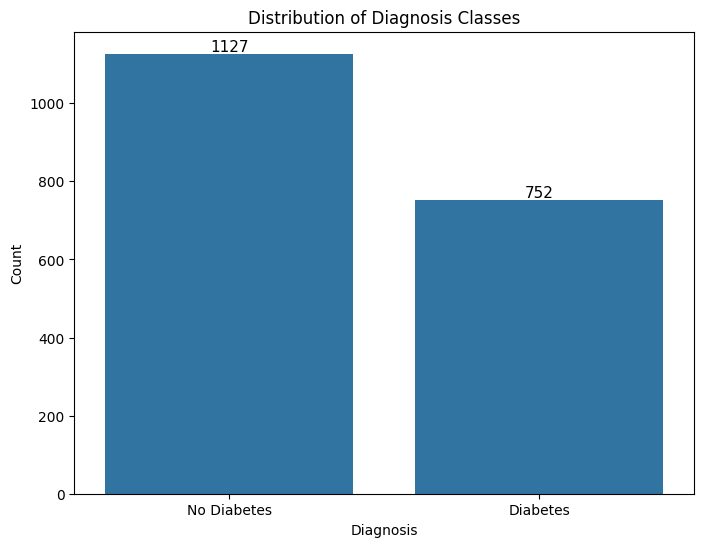

In [ ]:
diagnosis_counts = df['Diagnosis'].value_counts()
diagnosis_percentages = df['Diagnosis'].value_counts(normalize=True) * 100

print(diagnosis_percentages)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=diagnosis_counts.index, y=diagnosis_counts.values)
plt.title('Distribution of Diagnosis Classes')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### Categorical Feature Distributions

All 1879 observations have the same value 'Confidential' for `DoctorInCharge`.

Some features show significant class imbalance, such as `PolycysticOvarySyndrome`, `GestationalDiabetes`, `HeavyMetalsExposure`, and `OccupationalExposureChemicals`. For example, in `PolycysticOvarySyndrome`, the 'No' category accounts for over 95% of observations. On the other hand, features like `Gender`, `Ethnicity`, `SocioeconomicStatus`, and `EducationLevel` show more balanced distributions across their categories.


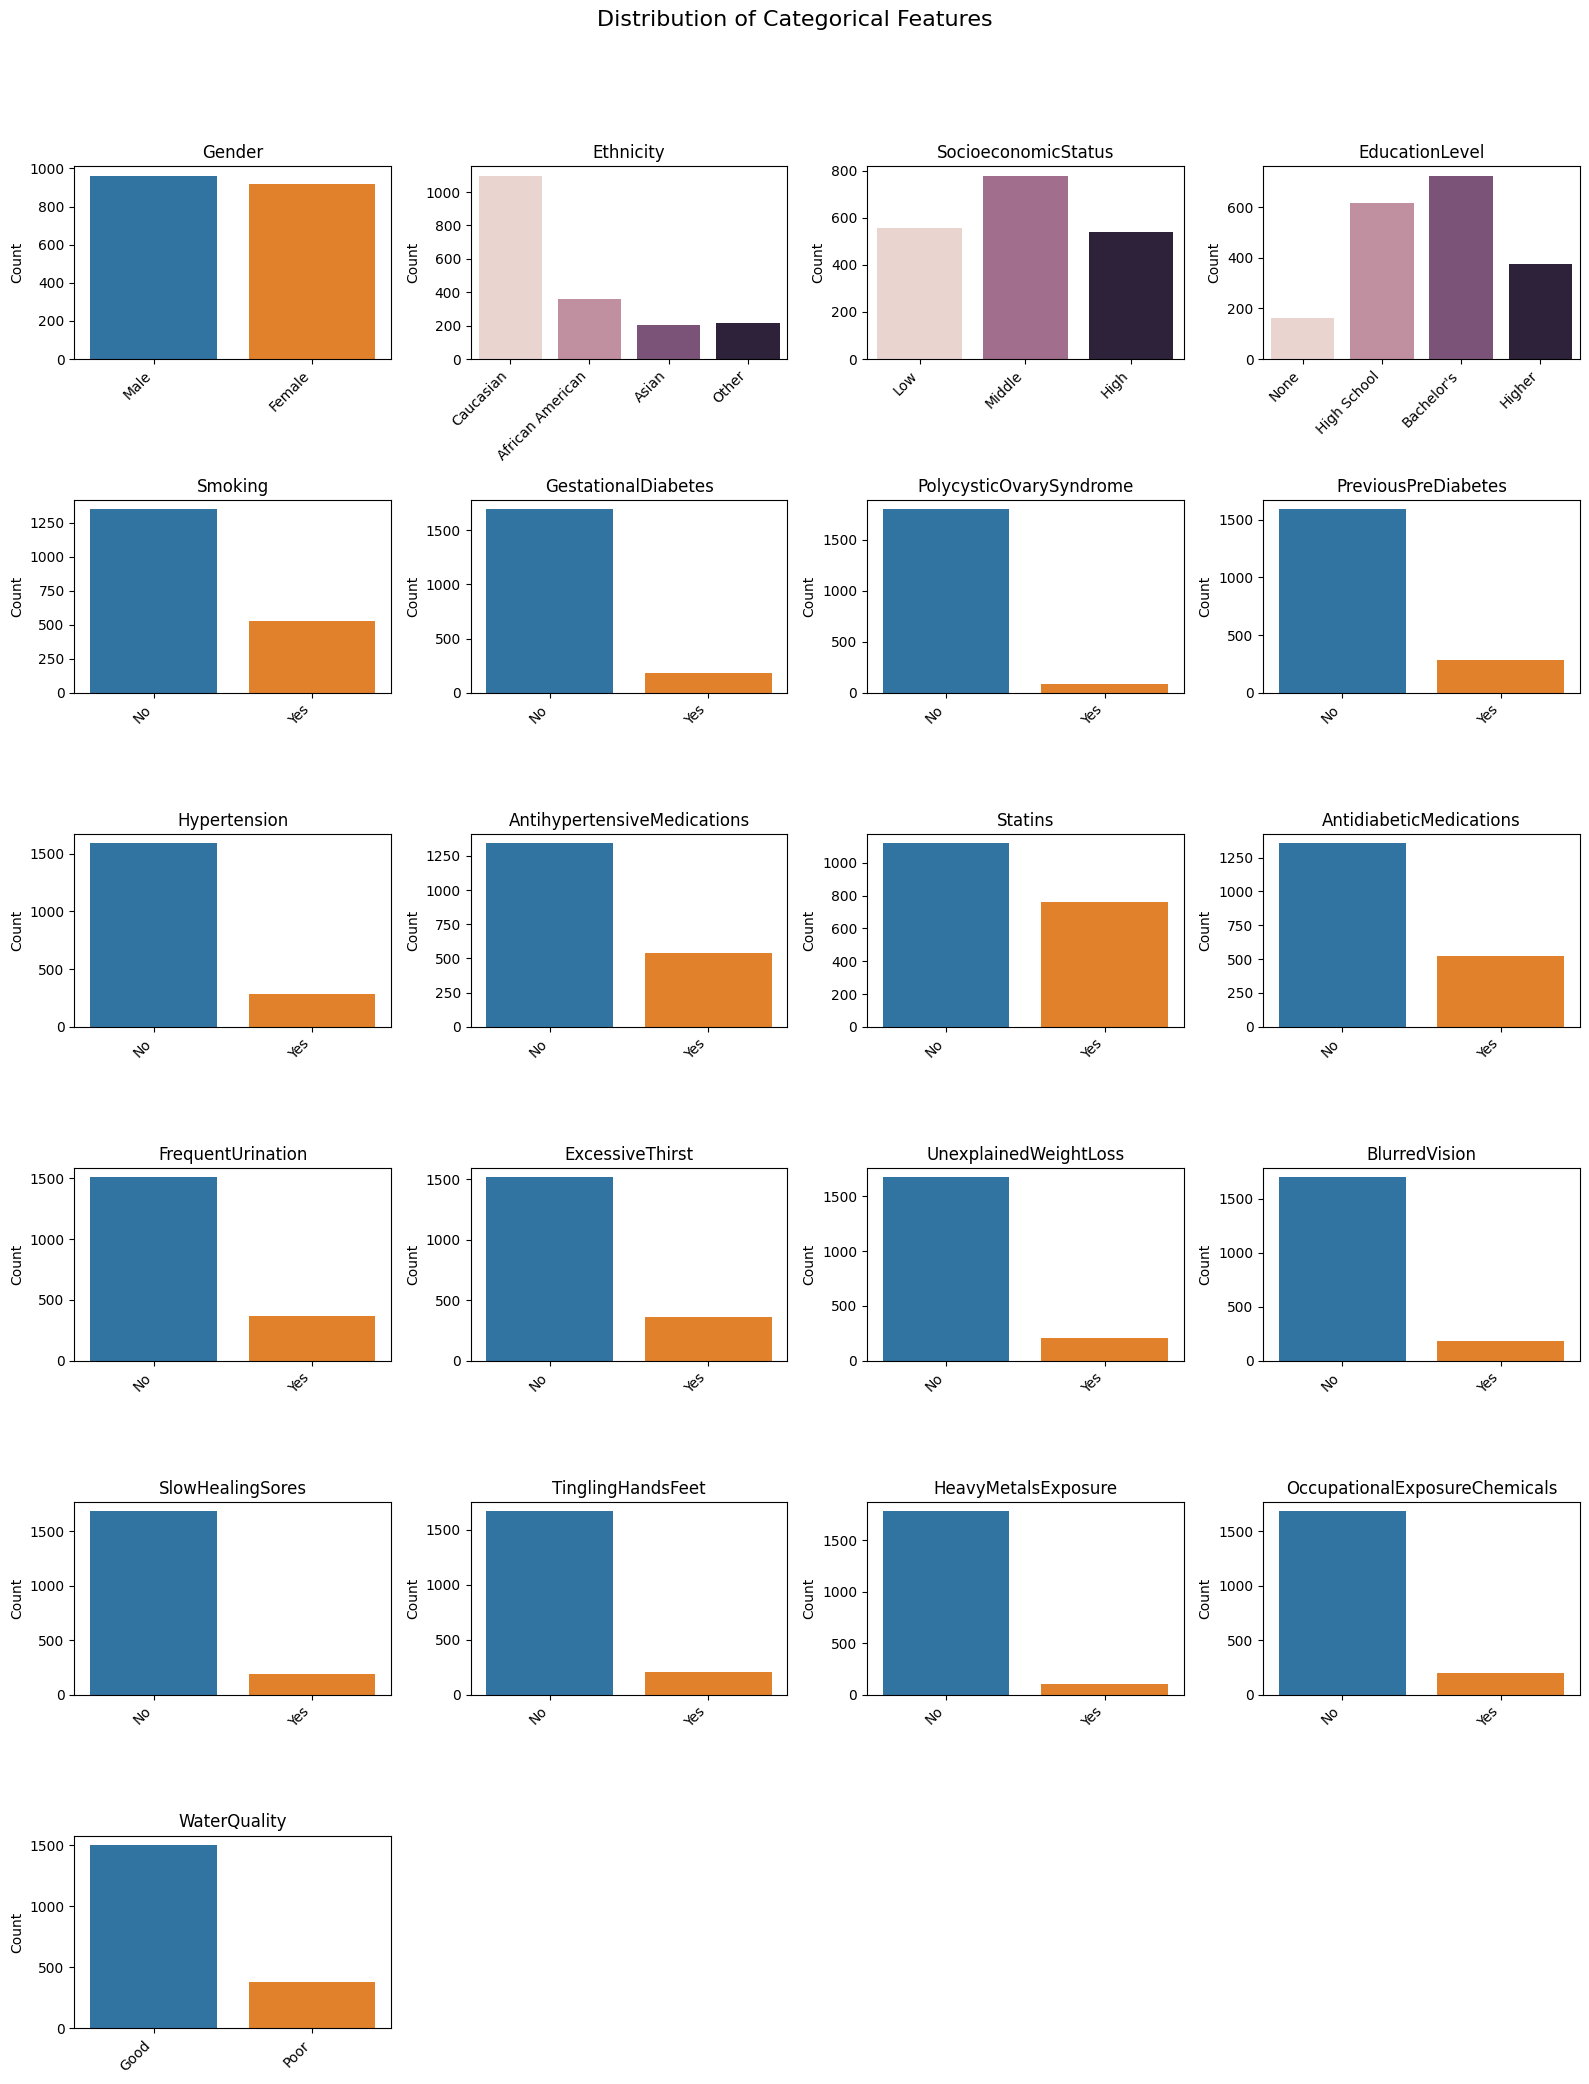

In [ ]:
categorical_feature_names = [
    'Gender',
    'Ethnicity',
    'SocioeconomicStatus',
    'EducationLevel',
    'Smoking',
    'GestationalDiabetes',
    'PolycysticOvarySyndrome',
    'PreviousPreDiabetes',
    'Hypertension',
    'AntihypertensiveMedications',
    'Statins',
    'AntidiabeticMedications',
    'FrequentUrination',
    'ExcessiveThirst',
    'UnexplainedWeightLoss',
    'BlurredVision',
    'SlowHealingSores',
    'TinglingHandsFeet',
    'HeavyMetalsExposure',
    'OccupationalExposureChemicals',
    'WaterQuality'
]

label_maps = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Ethnicity': {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'},
    'SocioeconomicStatus': {0: 'Low', 1: 'Middle', 2: 'High'},
    'EducationLevel': {0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'},
    'Smoking': {0: 'No', 1: 'Yes'},
    'GestationalDiabetes': {0: 'No', 1: 'Yes'},
    'PolycysticOvarySyndrome': {0: 'No', 1: 'Yes'},
    'PreviousPreDiabetes': {0: 'No', 1: 'Yes'},
    'Hypertension': {0: 'No', 1: 'Yes'},
    'AntihypertensiveMedications': {0: 'No', 1: 'Yes'},
    'Statins': {0: 'No', 1: 'Yes'},
    'AntidiabeticMedications': {0: 'No', 1: 'Yes'},
    'FrequentUrination': {0: 'No', 1: 'Yes'},
    'ExcessiveThirst': {0: 'No', 1: 'Yes'},
    'UnexplainedWeightLoss': {0: 'No', 1: 'Yes'},
    'BlurredVision': {0: 'No', 1: 'Yes'},
    'SlowHealingSores': {0: 'No', 1: 'Yes'},
    'TinglingHandsFeet': {0: 'No', 1: 'Yes'},
    'HeavyMetalsExposure': {0: 'No', 1: 'Yes'},
    'OccupationalExposureChemicals': {0: 'No', 1: 'Yes'},
    'WaterQuality': {0: 'Good', 1: 'Poor'}
}

n_features = len(categorical_feature_names)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3.5))
plt.suptitle('Distribution of Categorical Features', y=1.02, fontsize=16)

for i, feature in enumerate(categorical_feature_names):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=df[feature], ax=ax, hue=df[feature], legend=False)
    ax.set_title(f'{feature}')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    if feature in label_maps:
        current_ticks = ax.get_xticks()
        ax.set_xticks(current_ticks)
        labels = [label_maps[feature][int(item.get_text())] for item in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha='right')
    else:
        plt.xticks(rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Outlier Analysis for Continuous Features

Based on the box plots below, we can confirm there are no outliers in any of the useful continous features (excluding `PatientID`).

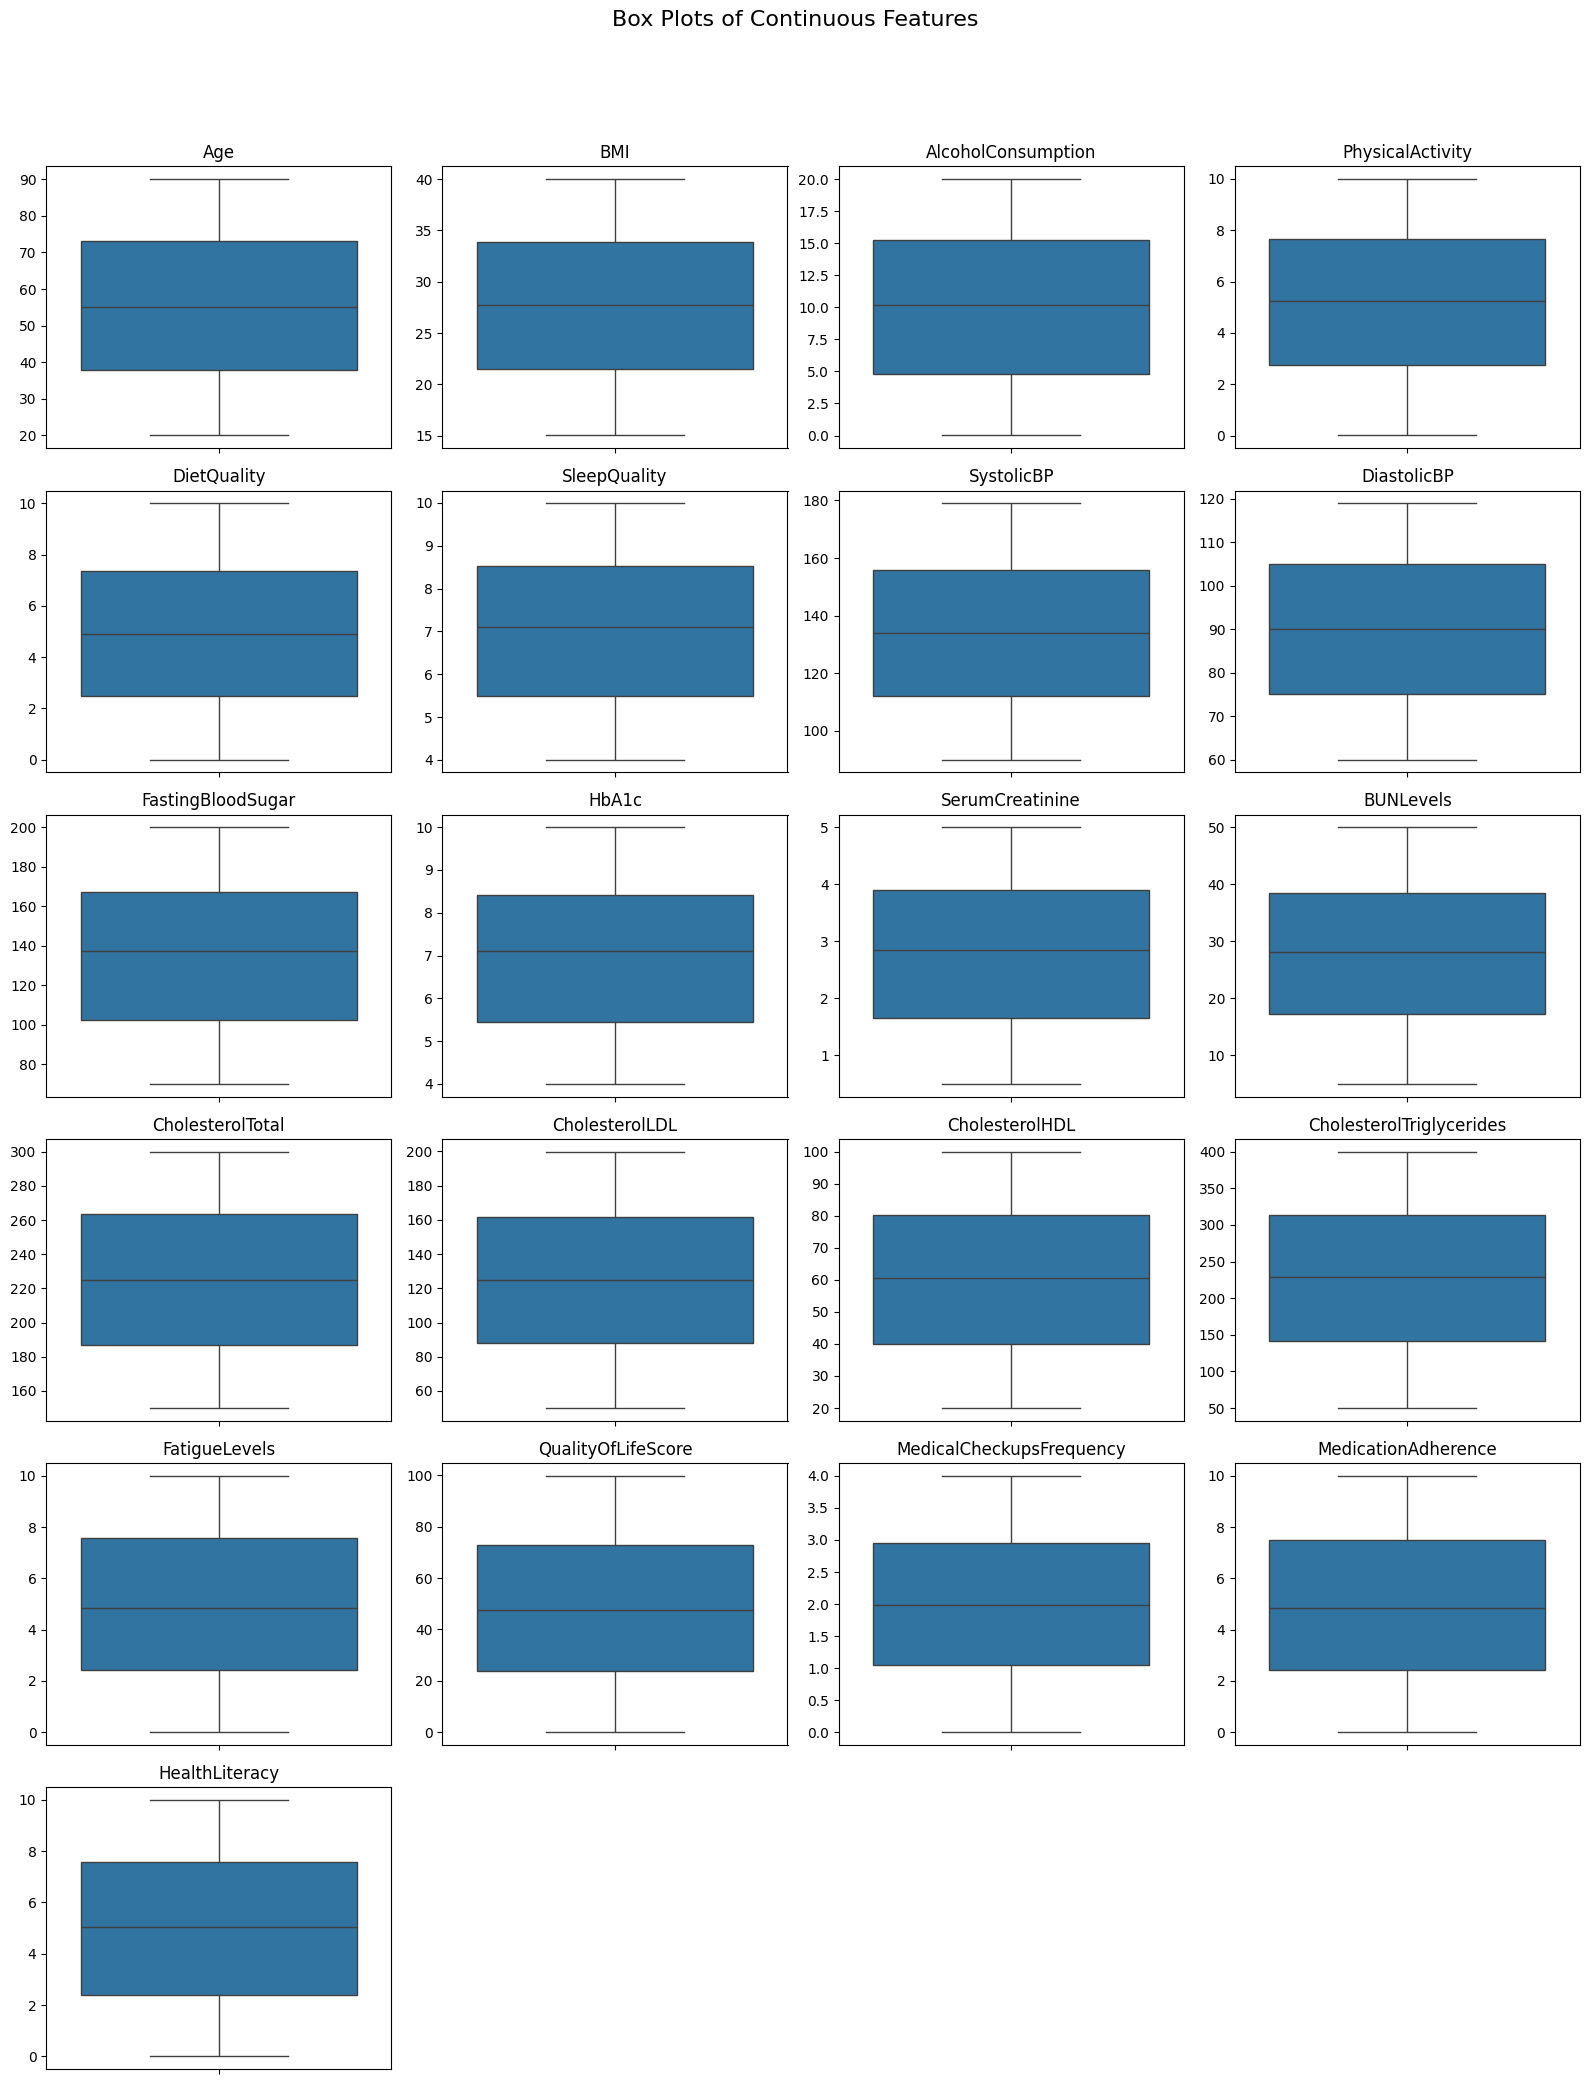

In [ ]:
continuous_feature_names = [col_name for col_name, _ in continuous_features]

continuous_feature_names = [f for f in continuous_feature_names if f != 'PatientID']

n_features_cont = len(continuous_feature_names)
n_cols_cont = 4
n_rows_cont = (n_features_cont + n_cols_cont - 1) // n_cols_cont

plt.figure(figsize=(n_cols_cont * 4, n_rows_cont * 3.5))
plt.suptitle('Box Plots of Continuous Features', y=1.02, fontsize=16)

for i, feature in enumerate(continuous_feature_names):
    ax = plt.subplot(n_rows_cont, n_cols_cont, i + 1)
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(f'{feature}')
    ax.set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Feature-Feature Correlation

We ignore `PatientID` and `DoctorInCharge` since they don't tell us anything useful. Based on the correlation heatmap, we can see there are no linear relationships between any pair of features. Particularly, for continuous features, PCA will not be useful.

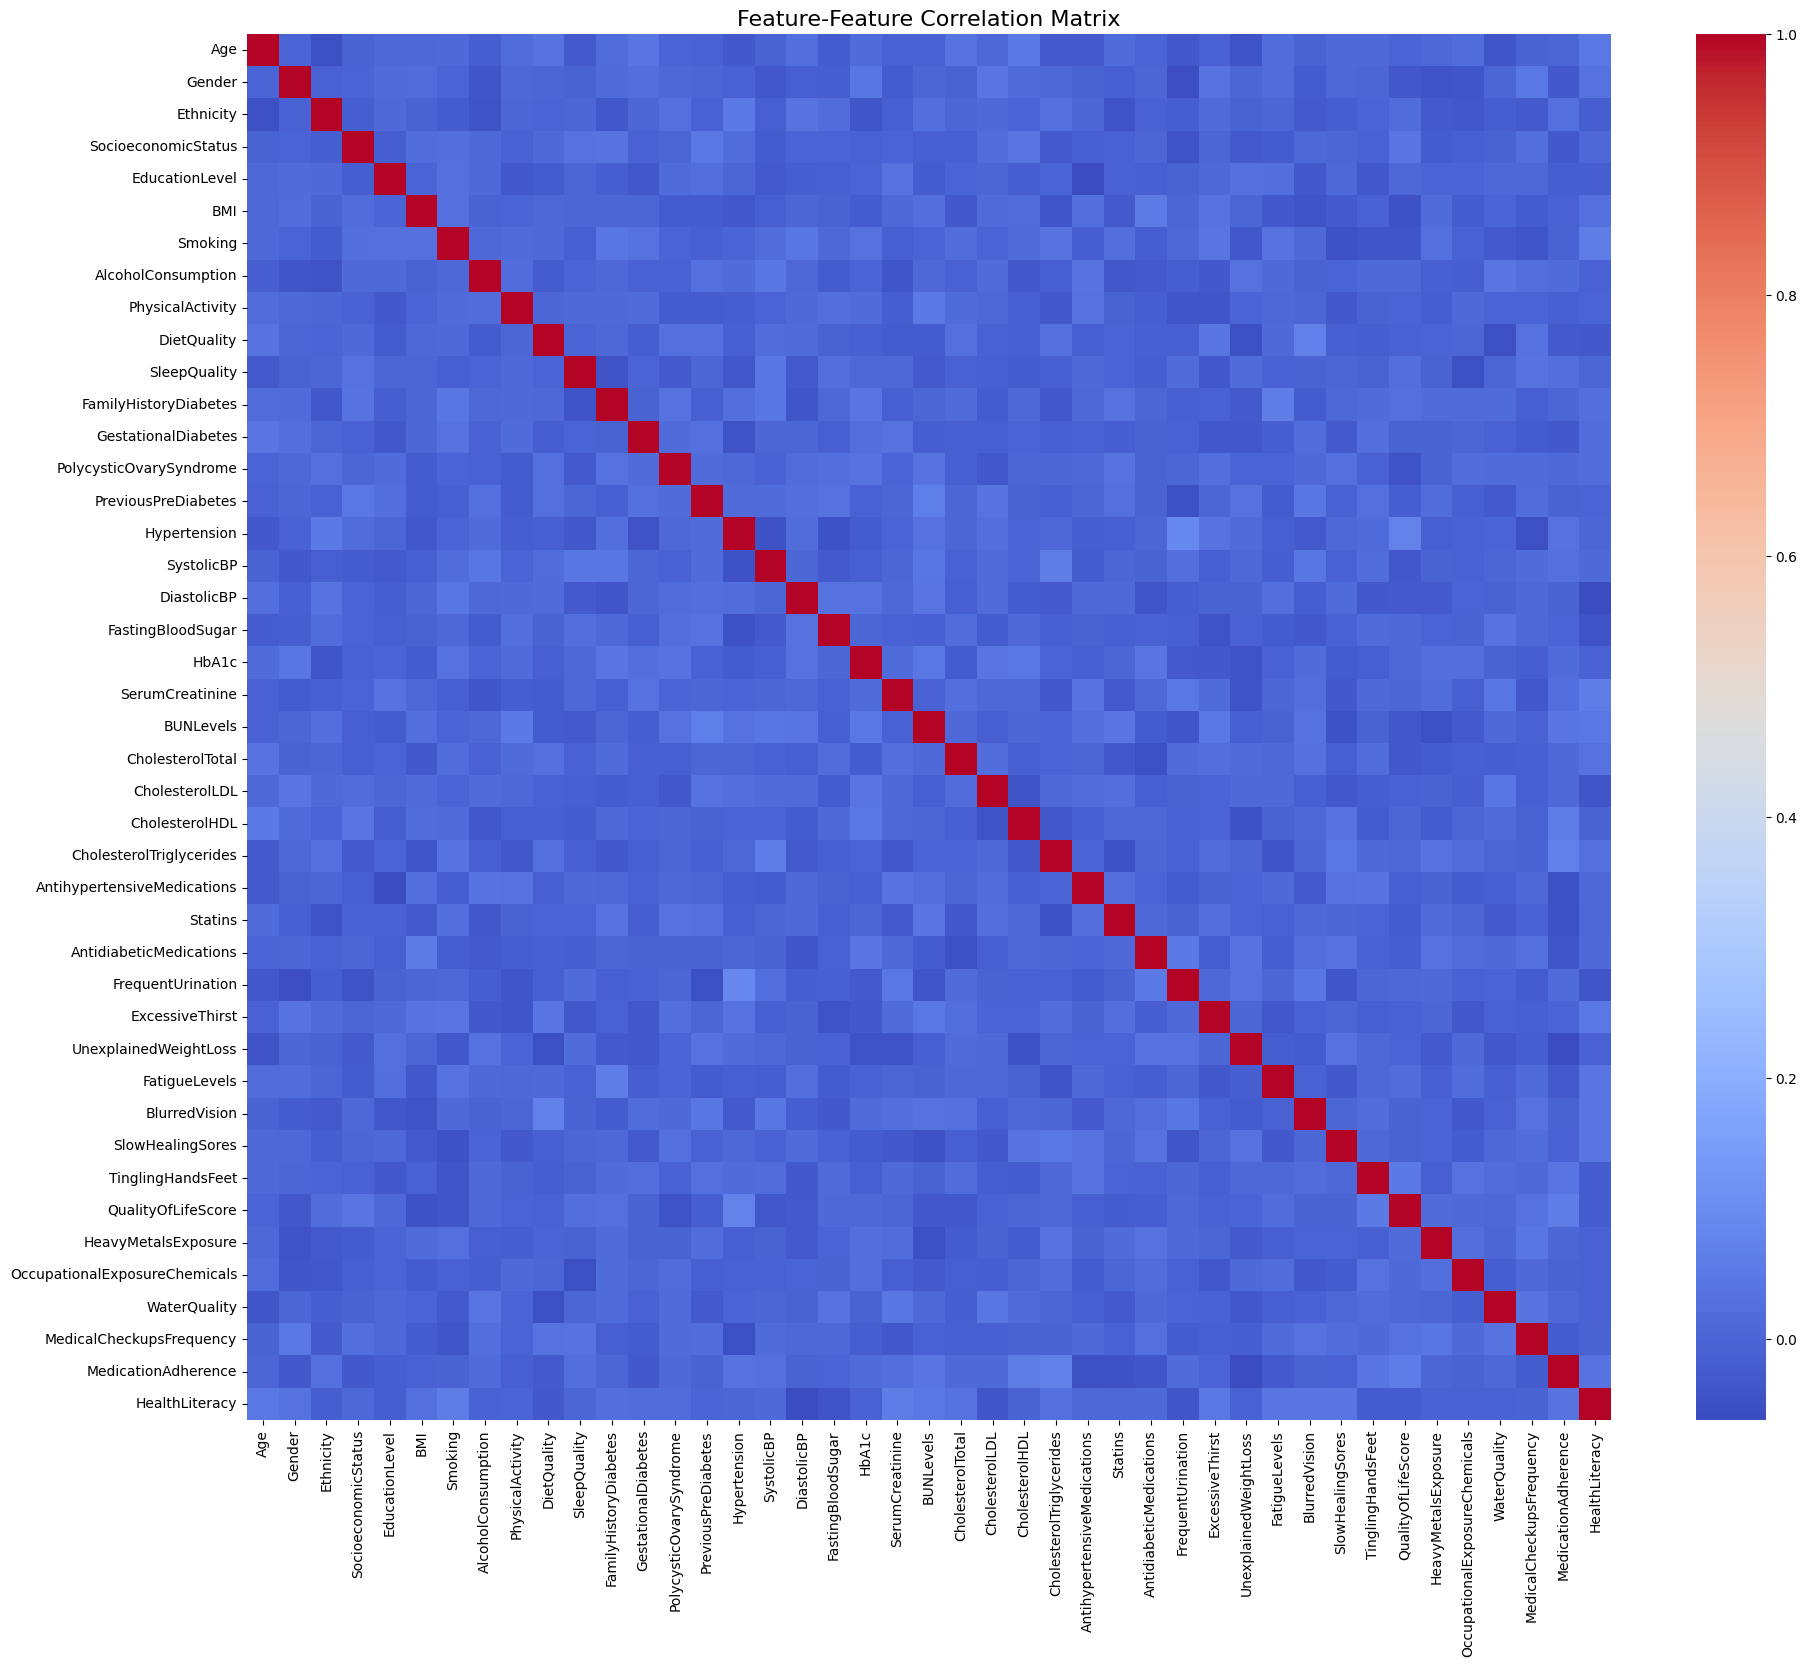

In [ ]:
plt.figure(figsize=(22, 18))
sns.heatmap(df.drop(columns=['Diagnosis', 'PatientID', 'DoctorInCharge'], axis=1).corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Feature-Feature Correlation Matrix', fontsize=16)
plt.show()

### Feature-Target Correlation

For continuous features, `FastingBloodSugar` and `HbA1c` show the strongest positive correlations (~0.45) with `Diagnosis`, while `SystolicBP` and `DietQuality` are the only ones with a slight negative correlation.

For categorical features, `FrequentUrination`, `Hypertension`, and `ExcessiveThirst` are the most positively correlated with `Diagnosis`, while `Statins`, `AntihypertensiveMedications`, and `Ethnicity` show a slight negative correlation.


In [ ]:
df_processed = df.drop(columns=['PatientID', 'DoctorInCharge'], axis=1)

categorical_correlations = df_processed[categorical_feature_names].corrwith(df_processed['Diagnosis']).sort_values(ascending=False)
continuous_correlations = df_processed[continuous_feature_names].corrwith(df_processed['Diagnosis']).sort_values(ascending=False)

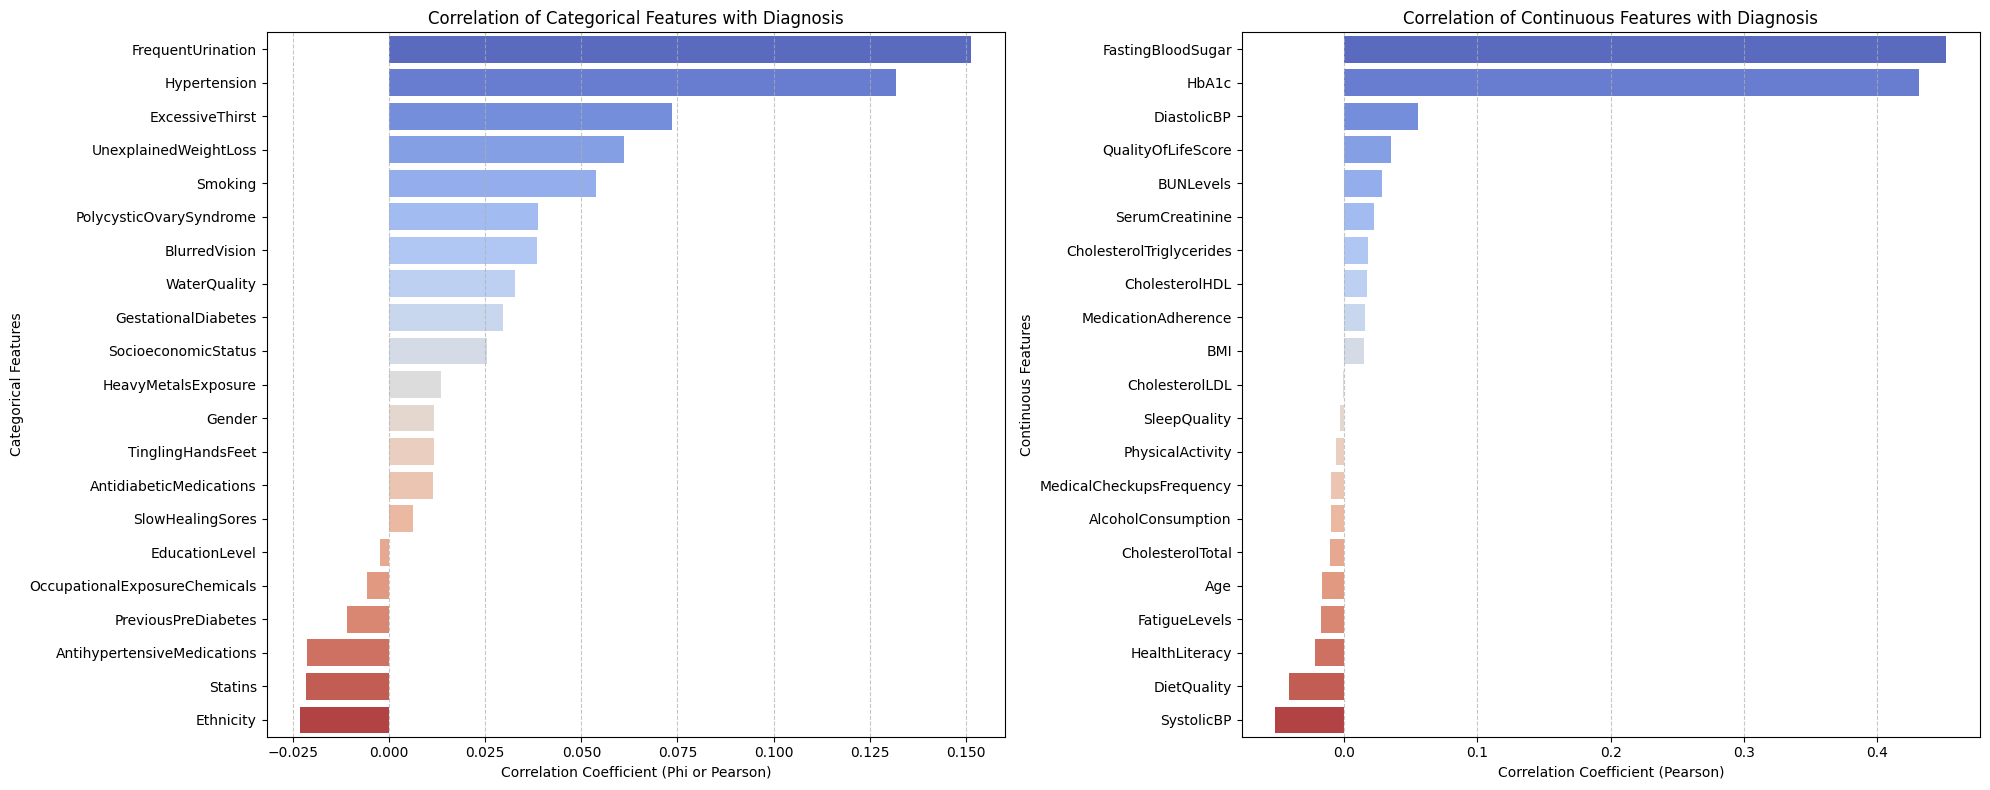

In [ ]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
sns.barplot(x=categorical_correlations.values, y=categorical_correlations.index, hue=categorical_correlations.index, palette='coolwarm', legend=False)
plt.title('Correlation of Categorical Features with Diagnosis')
plt.xlabel('Correlation Coefficient (Phi or Pearson)')
plt.ylabel('Categorical Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(x=continuous_correlations.values, y=continuous_correlations.index, hue=continuous_correlations.index, palette='coolwarm', legend=False)
plt.title('Correlation of Continuous Features with Diagnosis')
plt.xlabel('Correlation Coefficient (Pearson)')
plt.ylabel('Continuous Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Pairwise Scatter Plots of Key Continuous Features


We'll visualize some key continuous features pairwise to identify linear, non-linear relationships, or clusters.

<Figure size 1500x1500 with 0 Axes>

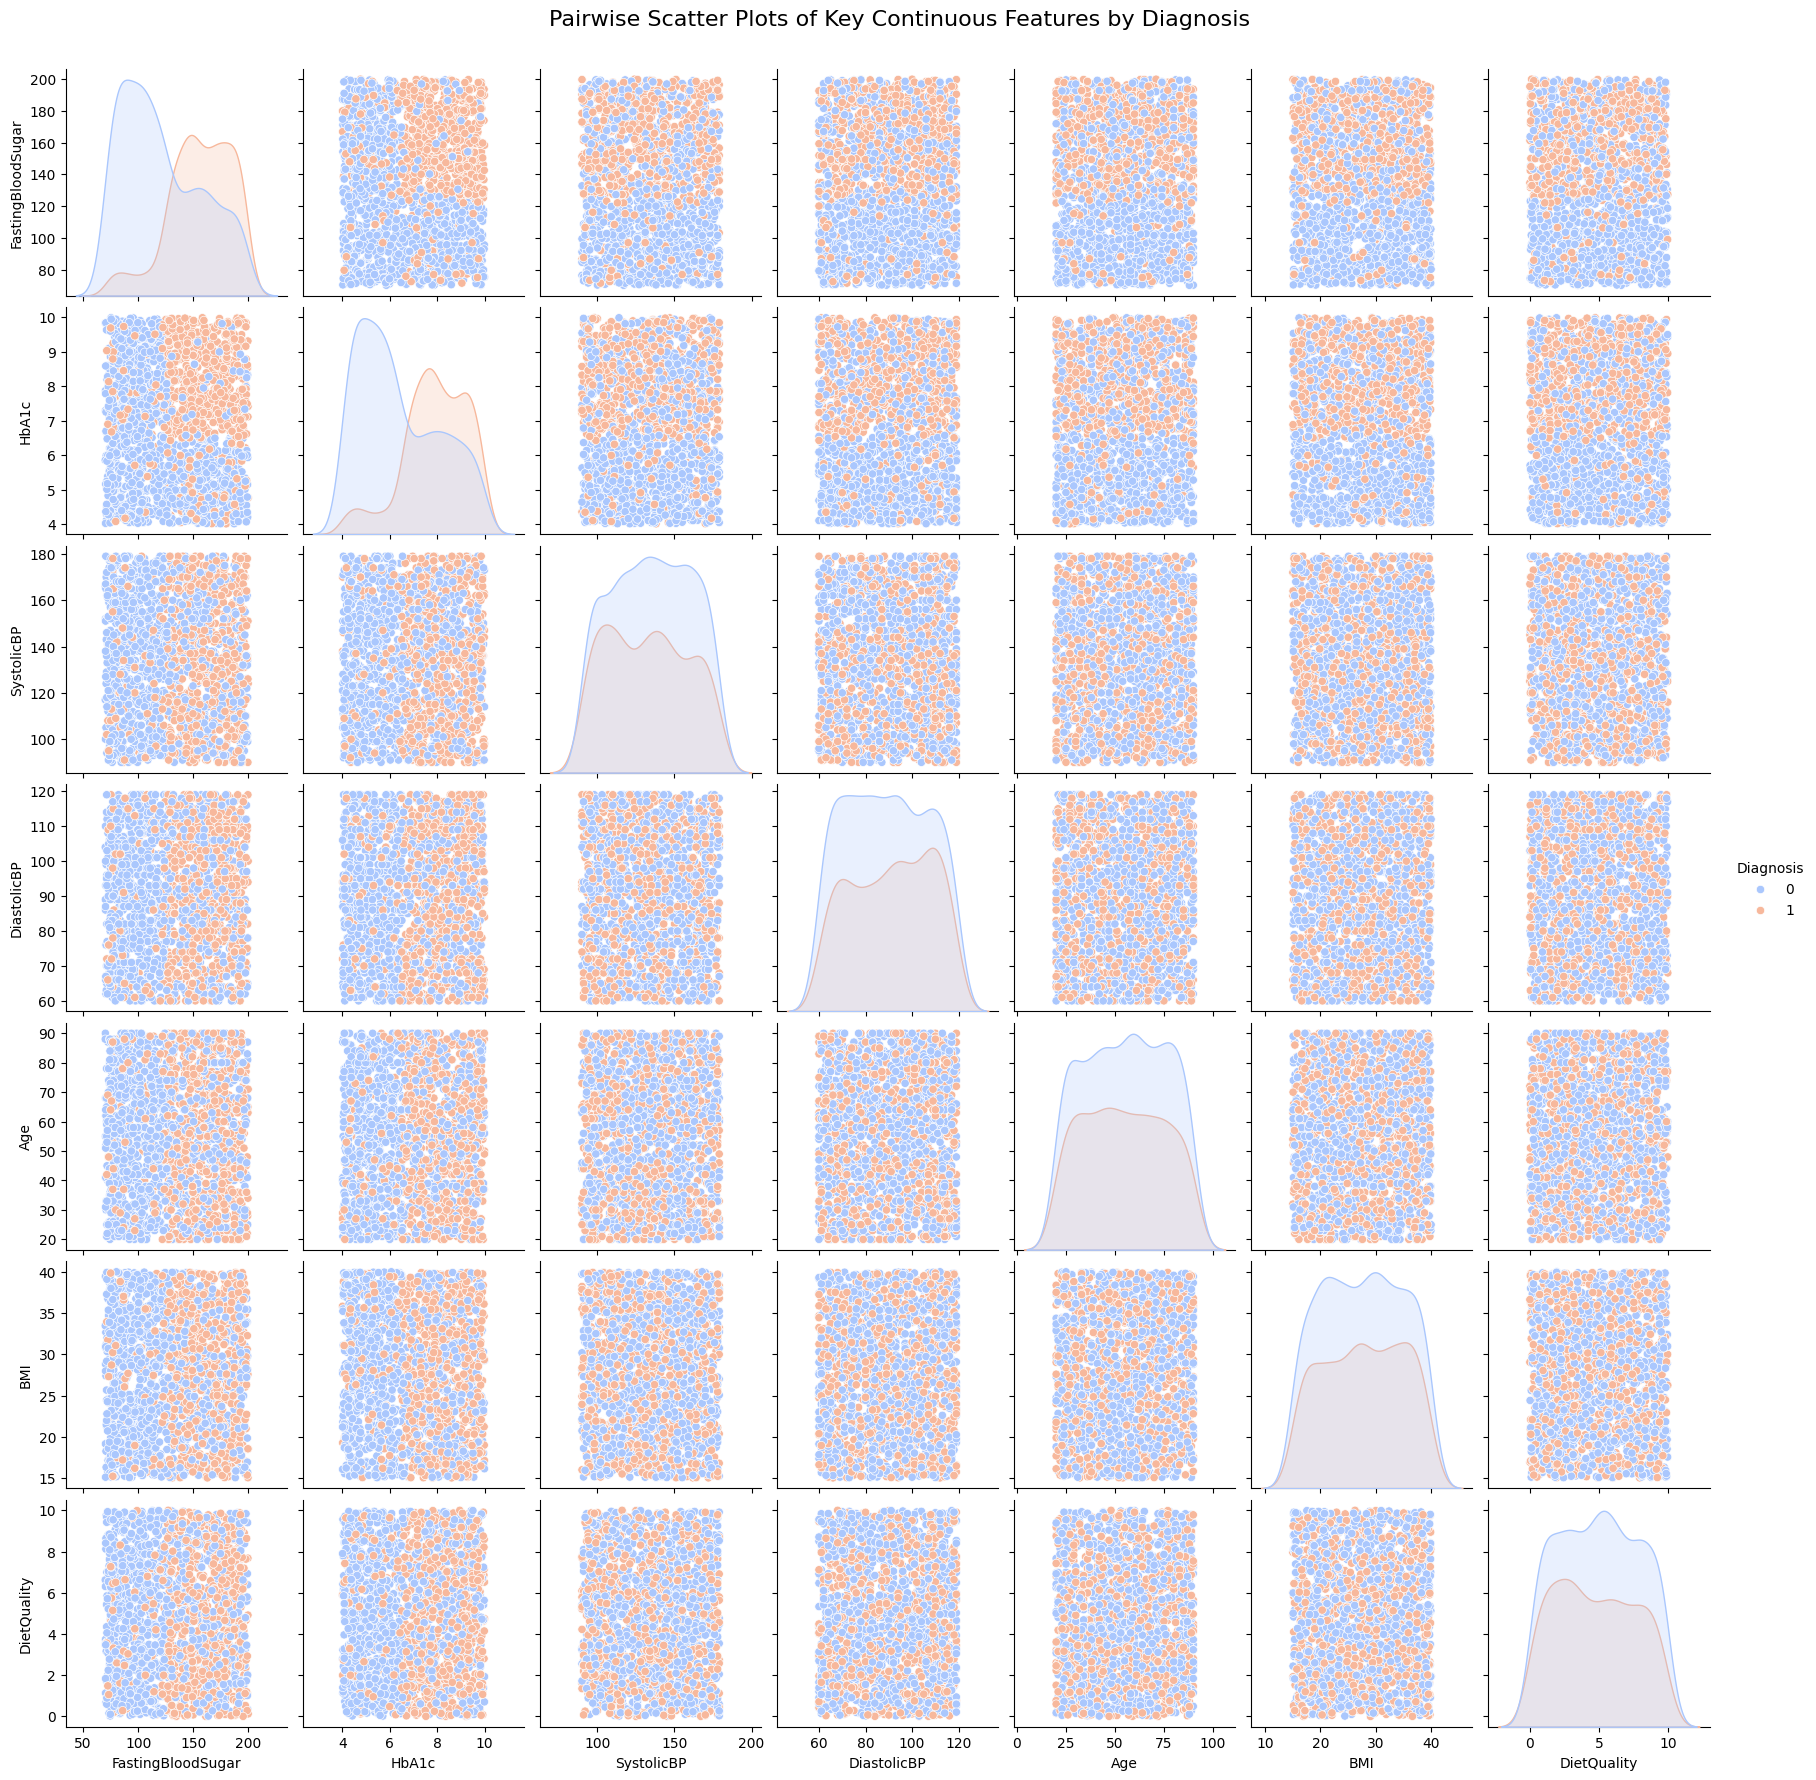

In [ ]:
selected_continuous_features = [
    'FastingBloodSugar', 'HbA1c', 'SystolicBP', 'DiastolicBP',
    'Age', 'BMI', 'DietQuality'
]

df_pairplot = df.drop(columns=['PatientID', 'DoctorInCharge'])[selected_continuous_features + ['Diagnosis']]

plt.figure(figsize=(15, 15))
sns.pairplot(df_pairplot, hue='Diagnosis', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairwise Scatter Plots of Key Continuous Features by Diagnosis', y=1.02, fontsize=16)
plt.show()

Based on the pairwise scatter plots, `FastingBloodSugar` and `HbA1c` show the most distinct separation between diagnosis groups, which matches what we know about their strong correlation with diabetes. Other features show strong overlap, suggesting complex or non-linear relationships.

## Data Preprocessing

We'll remove `PatientID` as it's just an identifier and `DoctorInCharge` as it was found to be a constant column, providing no useful information for our models.

In [ ]:
df_processed = df.drop(columns=['PatientID', 'DoctorInCharge'], axis=1)

Then, we'll split our processed data into features (`X`) and the target variable (`y`), which is 'Diagnosis'.

In [ ]:
X = df_processed.drop('Diagnosis', axis=1)
y = df_processed['Diagnosis']

We'll also standardize the input features using `StandardScaler` to make sure that they contribute equally to our training models.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,BlurredVision,SlowHealingSores,TinglingHandsFeet,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy
0,-0.538416,-0.975292,0.233251,1.318079,-0.789795,0.736909,1.597493,-0.946653,-0.965393,0.001057,...,-0.324491,-0.338337,2.826735,0.878460,-0.234575,-0.339313,-0.500998,-0.191010,-0.161696,0.753258
1,-0.197125,1.025334,-0.721604,0.010439,0.339600,1.701079,-0.625981,-1.440586,1.085505,1.411289,...,-0.324491,-0.338337,-0.353765,1.493421,-0.234575,-0.339313,1.996017,1.233118,0.345055,0.004409
2,1.655596,1.025334,-0.721604,0.010439,1.468995,-1.099636,-0.625981,-1.508511,0.316010,0.986171,...,-0.324491,-0.338337,-0.353765,0.207893,-0.234575,-0.339313,-0.500998,0.627192,1.372187,0.692848
3,-1.659799,1.025334,0.233251,0.010439,0.339600,0.652280,1.597493,-1.417635,1.206012,-0.032011,...,-0.324491,-0.338337,-0.353765,1.021122,-0.234575,-0.339313,1.996017,-0.523949,-0.629784,-0.100667
4,-1.367264,1.025334,-0.721604,0.010439,1.468995,-1.513271,-0.625981,0.907540,-0.200055,-0.824400,...,-0.324491,-0.338337,-0.353765,-0.374836,-0.234575,-0.339313,-0.500998,-0.693777,0.694190,0.984957


In [ ]:
processed_feature_names = X_scaled.columns.tolist()

continuous_feature_names = [f for f in processed_feature_names if f in continuous_feature_names]
categorical_feature_names = [f for f in processed_feature_names if f in categorical_feature_names]

print(continuous_feature_names)
print(categorical_feature_names)

['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'FatigueLevels', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'MedicationAdherence', 'HealthLiteracy']
['Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'Smoking', 'GestationalDiabetes', 'PolycysticOvarySyndrome', 'PreviousPreDiabetes', 'Hypertension', 'AntihypertensiveMedications', 'Statins', 'AntidiabeticMedications', 'FrequentUrination', 'ExcessiveThirst', 'UnexplainedWeightLoss', 'BlurredVision', 'SlowHealingSores', 'TinglingHandsFeet', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality']


Next, we'll perform some feature selection methods to determine if there are any features that can be removed or are less impactful.

We specifically choose **Variance Thresholding** to eliminate features with low or zero variance, **One-way F-ANOVA Test** to identify continuous features with statistically significant differences in means between the 'Diagnosis' groups, and **Chi-Square Test** to assess the statistical association between categorical features and the 'Diagnosis' target.

### Variance Thresholding

We'll use the default threshold of zero variance to get rid of any constant features.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
X_variance_thresholded = selector.fit_transform(X_scaled)

selected_features_variance_thresholding = X_scaled.columns[selector.get_support(indices=True)].tolist()

X_variance_thresholded = pd.DataFrame(X_variance_thresholded, columns=selected_features_variance_thresholding)

print(f"Number of features before variance thresholding: {X_scaled.shape[1]}")
print(f"Number of features after variance thresholding: {X_variance_thresholded.shape[1]}")

Number of features before variance thresholding: 43
Number of features after variance thresholding: 43


 All the features pass the threshold. We can further adjust the threshold if we want to, but that requires domain knowledge to select the most appriopriate number.

### ANOVA Test for Continuous Features vs. Diagnosis


We'll perform a one-way ANOVA test for each continuous feature to see if there are significant differences in their means across the two `Diagnosis` groups (No Diabetes vs. Diabetes).

A low p-value (typically < 0.05) suggests that there is a statistically significant difference in the means of the continuous feature between the groups.

In [ ]:
from scipy.stats import f_oneway

anova_results = {}

for feature in continuous_feature_names:
    group_0 = df_processed[df_processed['Diagnosis'] == 0][feature]
    group_1 = df_processed[df_processed['Diagnosis'] == 1][feature]

    f_statistic, p_value = f_oneway(group_0, group_1)

    anova_results[feature] = {'F-statistic': f_statistic, 'p-value': p_value}

    print(f"\nFeature: {feature}")
    print(f"  F-statistic: {f_statistic:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  (Statistically significant at alpha = 0.05)")
    else:
        print("  (Not statistically significant at alpha = 0.05)")

anova_df = pd.DataFrame.from_dict(anova_results, orient='index')
display(anova_df.sort_values(by='p-value'))


Feature: Age
  F-statistic: 0.5339
  P-value: 0.4650
  (Not statistically significant at alpha = 0.05)

Feature: BMI
  F-statistic: 0.3994
  P-value: 0.5275
  (Not statistically significant at alpha = 0.05)

Feature: AlcoholConsumption
  F-statistic: 0.1756
  P-value: 0.6753
  (Not statistically significant at alpha = 0.05)

Feature: PhysicalActivity
  F-statistic: 0.0772
  P-value: 0.7812
  (Not statistically significant at alpha = 0.05)

Feature: DietQuality
  F-statistic: 3.2276
  P-value: 0.0726
  (Not statistically significant at alpha = 0.05)

Feature: SleepQuality
  F-statistic: 0.0162
  P-value: 0.8987
  (Not statistically significant at alpha = 0.05)

Feature: SystolicBP
  F-statistic: 5.0491
  P-value: 0.0248
  (Statistically significant at alpha = 0.05)

Feature: DiastolicBP
  F-statistic: 5.7253
  P-value: 0.0168
  (Statistically significant at alpha = 0.05)

Feature: FastingBloodSugar
  F-statistic: 481.9153
  P-value: 0.0000
  (Statistically significant at alpha = 0.05)


,F-statistic,p-value
FastingBloodSugar,481.915334,2.916093e-95
HbA1c,428.487206,6.652215e-86
DiastolicBP,5.725349,1.681949e-02
SystolicBP,5.049136,2.475399e-02
DietQuality,3.227589,7.256796e-02
QualityOfLifeScore,2.321684,1.277503e-01
BUNLevels,1.502004,2.205170e-01
SerumCreatinine,0.952099,3.293114e-01
HealthLiteracy,0.881830,3.478216e-01
CholesterolTriglycerides,0.620262,4.310495e-01


The ANOVA results identified 4 statistically significant continuous features: `FastingBloodSugar` and `HbA1c` were the strongest, with F-statistics of 481.92 and 428.49 respectively, followed by `DiastolicBP` and `SystolicBP` with F-statistics of 5.73 and 5.05.

The remaining 17 continuous features showed no significant difference in means between the diagnosis classes.


### Chi-square Test for Categorical Features vs. Diagnosis


We'll perform a Chi-square test of independence for each categorical feature against the `Diagnosis` target. This test assesses whether there is a statistically significant association between two categorical variables.

A low p-value (typically < 0.05) suggests that there is a statistically significant association between the categorical feature and the `Diagnosis`.

In [ ]:
from scipy.stats import chi2_contingency

chi2_results = {}

for feature in categorical_feature_names:
    contingency_table = pd.crosstab(df_processed[feature], df_processed['Diagnosis'])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results[feature] = {'Chi2 Statistic': chi2, 'p-value': p_value, 'Degrees of Freedom': dof}

    print(f"\nFeature: {feature}")
    print(f"  Chi2 Statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  (Statistically significant at alpha = 0.05)")
    else:
        print("  (Not statistically significant at alpha = 0.05)")

chi2_df = pd.DataFrame.from_dict(chi2_results, orient='index')
display(chi2_df.sort_values(by='p-value'))


Feature: Gender
  Chi2 Statistic: 0.2135
  P-value: 0.6440
  (Not statistically significant at alpha = 0.05)

Feature: Ethnicity
  Chi2 Statistic: 2.3318
  P-value: 0.5065
  (Not statistically significant at alpha = 0.05)

Feature: SocioeconomicStatus
  Chi2 Statistic: 1.7747
  P-value: 0.4117
  (Not statistically significant at alpha = 0.05)

Feature: EducationLevel
  Chi2 Statistic: 1.5953
  P-value: 0.6605
  (Not statistically significant at alpha = 0.05)

Feature: Smoking
  Chi2 Statistic: 5.2031
  P-value: 0.0225
  (Statistically significant at alpha = 0.05)

Feature: GestationalDiabetes
  Chi2 Statistic: 1.4517
  P-value: 0.2283
  (Not statistically significant at alpha = 0.05)

Feature: PolycysticOvarySyndrome
  Chi2 Statistic: 2.4589
  P-value: 0.1169
  (Not statistically significant at alpha = 0.05)

Feature: PreviousPreDiabetes
  Chi2 Statistic: 0.1703
  P-value: 0.6799
  (Not statistically significant at alpha = 0.05)

Feature: Hypertension
  Chi2 Statistic: 31.9390
  P-val

,Chi2 Statistic,p-value,Degrees of Freedom
FrequentUrination,42.356556,7.606096e-11,1
Hypertension,31.938976,1.590927e-08,1
ExcessiveThirst,9.781116,1.763133e-03,1
UnexplainedWeightLoss,6.607502,1.015500e-02,1
Smoking,5.203067,2.254707e-02,1
BlurredVision,2.501827,1.137143e-01,1
PolycysticOvarySyndrome,2.458890,1.168613e-01,1
WaterQuality,1.866468,1.718802e-01,1
GestationalDiabetes,1.451697,2.282559e-01,1
Statins,0.789857,3.741433e-01,1


The Chi-Square results identified 6 statistically significant categorical features: `FrequentUrination` and `Hypertension` were the strongest with chi-square statistics of 42.36 and 31.94 respectively, followed by `ExcessiveThirst`, `UnexplainedWeightLoss`, `Smoking`, and `FamilyHistoryDiabetes`.

The remaining 16 categorical features showed no significant association with the target variable.


### Splitting Data for Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1409, 43)
X_test shape: (470, 43)
y_train shape: (1409,)
y_test shape: (470,)


## Model Training and Evaluations

We'll examine 4 models: `Logistic Regression`, `Random Forest`, `Gradient Boosting` (`XGBoost` since we have imbalanced classes) and `SVC` (with a RBF kernel), with Logistic Regression as our base model.

After training, we first evaluate our models on a single test set split. To ensure our models are reliable and not just performing well on one specific data arrangement, we then use the **stratified 5-fold cross-validation** technique.

This method involves repeatedly splitting the data, training the model, and testing it. Averaging these results gives us a much more stable and dependable measure of performance.

For diabetes risk screening, this reliability is critical: it helps ensure the model accurately identifies high-risk individuals and avoids both missing actual cases and generating unnecessary false alarms across a diverse range of patients.

Finally, we'll compare the performance of our different model types (linear versus non-linear) based on these comprehensive evaluations.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

### Single-Split Evaluation


In [ ]:
def evaluate_model(model, model_name, X_test, y_test, results_dict):
    """Trains a model, makes predictions, and stores evaluation metrics."""
    print(f"\n--- Evaluating {model_name} ---")

    # Predict on the test data
    y_pred = model.predict(X_test)

    # For ROC AUC, we need probabilities
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else: # Some models like SVC with 'decision_function' don't have predict_proba by default
        roc_auc = None # Or implement decision_function for ROC AUC if needed

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # Handle cases with no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    conf_matrix = confusion_matrix(y_test, y_pred)
    # Calculate True Negative, False Positive, False Negative, True Positive
    # For a binary classification confusion matrix: [[TN, FP], [FN, TP]]
    TN, FP, FN, TP = conf_matrix.ravel()
    # Calculate Specificity
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")
    else:
        print("ROC AUC Score: Not available (model lacks predict_proba)")
    print("Confusion Matrix:")
    print(conf_matrix)

    results_dict[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Specificity': specificity,
        'ROC AUC': roc_auc
    }

    return model

In [ ]:
sp_model_results = {}

log_reg_model = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
log_reg_model.fit(X_train, y_train)
evaluate_model(log_reg_model, 'Logistic Regression SP', X_test, y_test, sp_model_results)

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
evaluate_model(rf_model, 'Random Forests SP', X_test, y_test, sp_model_results)

scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

estimators = 100
gbc_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False, # Suppress the warning for this parameter
    eval_metric='logloss', # Specify a valid evaluation metric
    scale_pos_weight=scale_pos_weight_value
)
gbc_model.fit(X_train, y_train)
evaluate_model(gbc_model, 'XGBoost SP', X_test, y_test, sp_model_results)

svc_model = SVC(random_state=42, class_weight='balanced', probability=True)
svc_model.fit(X_train, y_train)
evaluate_model(svc_model, 'SVC SP', X_test, y_test, sp_model_results)


--- Evaluating Logistic Regression SP ---
Accuracy: 0.8298
Precision: 0.7571
Recall: 0.8457
F1-Score: 0.7990
Specificity: 0.8191
ROC AUC Score: 0.9108
Confusion Matrix:
[[231  51]
 [ 29 159]]

--- Evaluating Random Forests SP ---
Accuracy: 0.9021
Precision: 0.9277
Recall: 0.8191
F1-Score: 0.8701
Specificity: 0.9574
ROC AUC Score: 0.9612
Confusion Matrix:
[[270  12]
 [ 34 154]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:02:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Evaluating XGBoost SP ---
Accuracy: 0.9447
Precision: 0.9402
Recall: 0.9202
F1-Score: 0.9301
Specificity: 0.9610
ROC AUC Score: 0.9591
Confusion Matrix:
[[271  11]
 [ 15 173]]

--- Evaluating SVC SP ---
Accuracy: 0.8468
Precision: 0.7788
Recall: 0.8617
F1-Score: 0.8182
Specificity: 0.8369
ROC AUC Score: 0.9181
Confusion Matrix:
[[236  46]
 [ 26 162]]


SVC(class_weight='balanced', probability=True, random_state=42)

### Stratified 5-fold Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

def evaluate_model_cv(model, model_name, X, y, n_splits=5):

    print(f"\n--- Evaluating {model_name} with {n_splits}-fold Cross-Validation ---")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    specificity_scores = []
    roc_auc_scores = []
    conf_matrices = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)

        accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
        precision_scores.append(precision_score(y_test_fold, y_pred_fold, zero_division=0))
        recall_scores.append(recall_score(y_test_fold, y_pred_fold, zero_division=0))
        f1_scores.append(f1_score(y_test_fold, y_pred_fold, zero_division=0))

        conf_matrix_fold = confusion_matrix(y_test_fold, y_pred_fold)
        conf_matrices.append(conf_matrix_fold)
        TN, FP, FN, TP = conf_matrix_fold.ravel()
        specificity_scores.append(TN / (TN + FP) if (TN + FP) != 0 else 0)

        if hasattr(model, 'predict_proba'):
            y_pred_proba_fold = model.predict_proba(X_test_fold)[:, 1]
            roc_auc_scores.append(roc_auc_score(y_test_fold, y_pred_proba_fold))
        else:
            roc_auc_scores.append(None)

    avg_roc_auc = np.mean([score for score in roc_auc_scores if score is not None]) if any(score is not None for score in roc_auc_scores) else None

    avg_metrics = {
        'Accuracy': np.mean(accuracy_scores),
        'Precision': np.mean(precision_scores),
        'Recall': np.mean(recall_scores),
        'F1-Score': np.mean(f1_scores),
        'Specificity': np.mean(specificity_scores),
        'ROC AUC': avg_roc_auc
    }

    print(f"  Average Accuracy: {avg_metrics['Accuracy']:.4f}")
    print(f"  Average Precision: {avg_metrics['Precision']:.4f}")
    print(f"  Average Recall: {avg_metrics['Recall']:.4f}")
    print(f"  Average F1-Score: {avg_metrics['F1-Score']:.4f}")
    print(f"  Average Specificity: {avg_metrics['Specificity']:.4f}")
    if avg_metrics['ROC AUC'] is not None:
        print(f"  Average ROC AUC Score: {avg_metrics['ROC AUC']:.4f}")
    else:
        print("  Average ROC AUC Score: Not available")

    total_conf_matrix = np.sum(conf_matrices, axis=0)
    print(f"\nAggregated Confusion Matrix:\n{total_conf_matrix}")

    return avg_metrics

In [ ]:
cv_model_results = {}

log_reg_model_cv = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
cv_model_results['Logistic Regression CV'] = evaluate_model_cv(log_reg_model_cv, 'Logistic Regression', X_scaled, y)

rf_model_cv = RandomForestClassifier(random_state=42, class_weight='balanced')
cv_model_results['Random Forest CV'] = evaluate_model_cv(rf_model_cv, 'Random Forest', X_scaled, y)

# Calculate scale_pos_weight for XGBoost (using the full dataset's class distribution for CV consistency)
# This mimics the single-split approach where it was calculated once based on the training set.
scale_pos_weight_value_for_cv = (y == 0).sum() / (y == 1).sum()
xgb_model_cv = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value_for_cv
)
cv_model_results['XGBoost CV'] = evaluate_model_cv(xgb_model_cv, 'XGBoost', X_scaled, y)

svc_model_cv = SVC(random_state=42, class_weight='balanced', probability=True)
cv_model_results['SVC CV'] = evaluate_model_cv(svc_model_cv, 'SVC', X_scaled, y)


--- Evaluating Logistic Regression with 5-fold Cross-Validation ---
  Average Accuracy: 0.8270
  Average Precision: 0.7626
  Average Recall: 0.8258
  Average F1-Score: 0.7927
  Average Specificity: 0.8279
  Average ROC AUC Score: 0.9053

Aggregated Confusion Matrix:
[[933 194]
 [131 621]]

--- Evaluating Random Forest with 5-fold Cross-Validation ---
  Average Accuracy: 0.9063
  Average Precision: 0.9438
  Average Recall: 0.8152
  Average F1-Score: 0.8742
  Average Specificity: 0.9672
  Average ROC AUC Score: 0.9554

Aggregated Confusion Matrix:
[[1090   37]
 [ 139  613]]

--- Evaluating XGBoost with 5-fold Cross-Validation ---
  Average Accuracy: 0.9340
  Average Precision: 0.9359
  Average Recall: 0.8963
  Average F1-Score: 0.9156
  Average Specificity: 0.9592
  Average ROC AUC Score: 0.9579

Aggregated Confusion Matrix:
[[1081   46]
 [  78  674]]

--- Evaluating SVC with 5-fold Cross-Validation ---
  Average Accuracy: 0.8361
  Average Precision: 0.7817
  Average Recall: 0.8192
  Av

In [ ]:
sp_results_df = pd.DataFrame(sp_model_results).T
cv_results_df = pd.DataFrame(cv_model_results).T

sp_results_df.index = [f'{idx} (Single Split)' for idx in sp_results_df.index]
cv_results_df.index = [f'{idx} (CV)' for idx in cv_results_df.index]

final_results_df = pd.concat([sp_results_df, cv_results_df])

display(final_results_df.sort_values(by=['ROC AUC', 'Recall', 'F1-Score', 'Specificity'], ascending=False))

,Accuracy,Precision,Recall,F1-Score,Specificity,ROC AUC
Random Forests SP (Single Split),0.902128,0.927711,0.819149,0.870056,0.957447,0.961210
XGBoost SP (Single Split),0.944681,0.940217,0.920213,0.930108,0.960993,0.959069
XGBoost CV (CV),0.934013,0.935921,0.896256,0.915577,0.959194,0.957905
Random Forest CV (CV),0.906338,0.943810,0.815214,0.874217,0.967182,0.955399
SVC SP (Single Split),0.846809,0.778846,0.861702,0.818182,0.836879,0.918138
Logistic Regression SP (Single Split),0.829787,0.757143,0.845745,0.798995,0.819149,0.910763
SVC CV (CV),0.836089,0.781739,0.819214,0.799883,0.847394,0.909398
Logistic Regression CV (CV),0.827041,0.762608,0.825845,0.792689,0.827898,0.905284


### Performance Comparison: Single-Split vs. Stratified Cross Validation

We trained and evaluated four classification models: `Logistic Regression`, `Random Forest`, `XGBoost`, and `Support Vector Machine (SVC)`, using `Accuracy`, `Precision`, `Recall`, `F1-Score`, `Specificity`, and `ROC AUC` as key metrics, across both a single-test split and 5-fold cross-validation.

#### Single-Test Split

* `XGBoost` was the best-performing model, achieving the highest F1-Score (0.9301), Accuracy (0.9447), and ROC AUC (0.9591), with a strong balance between Precision (0.9402) and Recall (0.9202) — critical for diabetes screening.
* `Random Forest` ranked second, with an F1-Score of 0.8701 and ROC AUC of 0.9612. Its lower Recall (0.8191) suggests it misses more actual cases.
* `SVC` achieved an F1-Score of 0.8182 and ROC AUC of 0.9181, with a relatively high Recall (0.8617) but lower Precision (0.7789).
* `Logistic Regression` was the weakest, with an F1-Score of 0.7990, Accuracy of 0.8298, and ROC AUC of 0.9108.

#### Cross-Validation

* `XGBoost` maintained the highest average F1-Score (0.9156), Accuracy (0.9340), and ROC AUC (0.9579), with well-balanced Precision (0.9359) and Recall (0.8963), confirming it as the most robust model.
* `Random Forest` showed stable performance with an average F1-Score of 0.8742 and ROC AUC of 0.9554. Its high Precision (0.9438) and consistent Recall (0.8152) aligned closely with single-split results.
* `SVC` returned an average F1-Score of 0.7999 and ROC AUC of 0.9094, with balanced Precision (0.7817) and Recall (0.8192).
* `Logistic Regression` was again the weakest, with an average F1-Score of 0.7927, Accuracy of 0.8270, and ROC AUC of 0.9053.

#### Comparison of Linear vs. Non-linear Models

Non-linear models consistently outperformed `Logistic Regression` across both evaluation methods, confirming that the relationship between features and diabetes diagnosis is complex and cannot be adequately captured by a linear decision boundary.

In the single-test split, `XGBoost` outperformed `Logistic Regression` by a margin of 0.1311 in F1-Score (0.9301 vs. 0.7990) and 0.0483 in ROC AUC (0.9591 vs. 0.9108). `Random Forest` showed a similar advantage, with an F1-Score of 0.8701 — 0.0711 higher than `Logistic Regression`. Even `SVC`, the weakest non-linear model, exceeded `Logistic Regression` in F1-Score (0.8182 vs. 0.7990) and ROC AUC (0.9181 vs. 0.9108). Cross-validation results followed the same pattern, with `XGBoost` maintaining a 0.1229 F1-Score lead (0.9156 vs. 0.7927) over `Logistic Regression`.

These confirm that the dataset's feature interactions require a non-linear approach, and that linear models alone are insufficient for reliable diabetes risk prediction.

#### Overall Conclusion

`XGBoost` and `Random Forest` are the top models for diabetes risk screening. `XGBoost`, in particular, offers the best balance of high Recall (catching actual cases) and high Precision (minimizing false alarms), and its stability across folds indicates strong generalization to unseen data. These results support the use of machine learning — especially XGBoost — as a reliable tool for early diabetes risk screening.

## Full Features vs. Accessible Features


To build a practical pre-screening tool for non-technical users, we retrained and evaluated our models using only accessible features, those that can be self-reported or easily observed without requiring a medical visit. This allows risk assessment based on readily available information, making early screening possible for users without regular access to healthcare.


* **Demographic/Lifestyle:** `Age`, `Gender`, `Ethnicity`, `SocioeconomicStatus`, `EducationLevel`, `BMI`, `Smoking`, `AlcoholConsumption`, `PhysicalActivity`, `DietQuality`, `SleepQuality`
* **Symptoms/Conditions:** `FrequentUrination`, `ExcessiveThirst`, `UnexplainedWeightLoss`, `BlurredVision`, `SlowHealingSores`, `TinglingHandsFeet`, `Hypertension`
* **Medical History:** `FamilyHistoryDiabetes`, `GestationalDiabetes`, `PolycysticOvarySyndrome`, `PreviousPreDiabetes`
* **Environmental:** `HeavyMetalsExposure`, `OccupationalExposureChemicals`, `WaterQuality`

> **Note:** Some features such as `Hypertension`, `PolycysticOvarySyndrome`, and `GestationalDiabetes` are self-reported only if the user has been previously diagnosed, which may not always be the case.

In [ ]:
accessible_features = [
    'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI',
    'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'FamilyHistoryDiabetes', 'GestationalDiabetes', 'PolycysticOvarySyndrome',
    'PreviousPreDiabetes', 'Hypertension', 'FrequentUrination', 'ExcessiveThirst',
    'UnexplainedWeightLoss', 'BlurredVision', 'SlowHealingSores', 'TinglingHandsFeet',
    'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality'
]

X_accessible = df_processed[accessible_features]

scaler_accessible = StandardScaler()
X_accessible_scaled = scaler_accessible.fit_transform(X_accessible)
X_accessible_scaled = pd.DataFrame(X_accessible_scaled, columns=X_accessible.columns)

X_train_accessible, X_test_accessible, y_train_accessible, y_test_accessible = train_test_split(
    X_accessible_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"X_train_accessible shape: {X_train_accessible.shape}")
print(f"X_test_accessible shape: {X_test_accessible.shape}")
print(f"y_train_accessible shape: {y_train_accessible.shape}")
print(f"y_test_accessible shape: {y_test_accessible.shape}")

X_train_accessible shape: (1409, 25)
X_test_accessible shape: (470, 25)
y_train_accessible shape: (1409,)
y_test_accessible shape: (470,)


### Model Training and Evaluation (5-fold Cross Validation)

In [ ]:
cv_results_accessible = {}

log_reg_model_cv_accessible = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
cv_results_accessible['Logistic Regression CV (Accessible)'] = evaluate_model_cv(log_reg_model_cv_accessible, 'Logistic Regression (Accessible)', X_accessible_scaled, y)

rf_model_cv_accessible = RandomForestClassifier(random_state=42, class_weight='balanced')
cv_results_accessible['Random Forest CV (Accessible)'] = evaluate_model_cv(rf_model_cv_accessible, 'Random Forest (Accessible)', X_accessible_scaled, y)

# Evaluate XGBoost with CV (accessible features)
scale_pos_weight_value_for_cv_accessible = (y == 0).sum() / (y == 1).sum()
xgb_model_cv_accessible = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value_for_cv_accessible
)
cv_results_accessible['XGBoost CV (Accessible)'] = evaluate_model_cv(xgb_model_cv_accessible, 'XGBoost (Accessible)', X_accessible_scaled, y)

# Evaluate SVC with CV (accessible features)
svc_model_cv_accessible = SVC(random_state=42, class_weight='balanced', probability=True)
cv_results_accessible['SVC CV (Accessible)'] = evaluate_model_cv(svc_model_cv_accessible, 'SVC (Accessible)', X_accessible_scaled, y)


--- Evaluating Logistic Regression (Accessible) with 5-fold Cross-Validation ---
  Average Accuracy: 0.5806
  Average Precision: 0.4781
  Average Recall: 0.5119
  Average F1-Score: 0.4939
  Average Specificity: 0.6264
  Average ROC AUC Score: 0.5994

Aggregated Confusion Matrix:
[[706 421]
 [367 385]]

--- Evaluating Random Forest (Accessible) with 5-fold Cross-Validation ---
  Average Accuracy: 0.6195
  Average Precision: 0.5623
  Average Recall: 0.2273
  Average F1-Score: 0.3215
  Average Specificity: 0.8811
  Average ROC AUC Score: 0.5701

Aggregated Confusion Matrix:
[[993 134]
 [581 171]]

--- Evaluating XGBoost (Accessible) with 5-fold Cross-Validation ---
  Average Accuracy: 0.5663
  Average Precision: 0.4528
  Average Recall: 0.4002
  Average F1-Score: 0.4247
  Average Specificity: 0.6770
  Average ROC AUC Score: 0.5461

Aggregated Confusion Matrix:
[[763 364]
 [451 301]]

--- Evaluating SVC (Accessible) with 5-fold Cross-Validation ---
  Average Accuracy: 0.5849
  Average Pre

In [ ]:
# Create DataFrames from the available results and add prefixes
cv_results_df = pd.DataFrame(cv_model_results).T
cv_results_accessible_df = pd.DataFrame(cv_results_accessible).T

cv_results_df.index = [f'{idx}' for idx in cv_results_df.index]
cv_results_accessible_df.index = [f'{idx}' for idx in cv_results_accessible_df.index]

# Concatenate all available results for final comparison
final_comparison_df = pd.concat([
    cv_results_df,
    cv_results_accessible_df
])

display(final_comparison_df.sort_values(by=['ROC AUC', 'Recall', 'F1-Score', 'Specificity'], ascending=False))

,Accuracy,Precision,Recall,F1-Score,Specificity,ROC AUC
XGBoost CV,0.934013,0.935921,0.896256,0.915577,0.959194,0.957905
Random Forest CV,0.906338,0.943810,0.815214,0.874217,0.967182,0.955399
SVC CV,0.836089,0.781739,0.819214,0.799883,0.847394,0.909398
Logistic Regression CV,0.827041,0.762608,0.825845,0.792689,0.827898,0.905284
Logistic Regression CV (Accessible),0.580624,0.478095,0.511912,0.493857,0.626395,0.599373
SVC CV (Accessible),0.584891,0.481450,0.457395,0.467976,0.669947,0.591203
Random Forest CV (Accessible),0.619472,0.562256,0.227294,0.321487,0.881101,0.570096
XGBoost CV (Accessible),0.566264,0.452795,0.400230,0.424740,0.677007,0.546063


### Performance Comparison: Full vs. Accessible Features

We evaluated all four models — `Logistic Regression`, `Random Forest`, `XGBoost`, and `SVC` — using both the full feature set and the accessible feature subset, with results compared across cross-validation averages.

#### Significant Performance Drop with Accessible Features

Across all models and metrics, there is a substantial drop in performance when switching from full to accessible features. This indicates that clinically obtained features such as `FastingBloodSugar`, `HbA1c`, `SystolicBP`, and `DiastolicBP` are highly discriminative for diabetes diagnosis and cannot be easily replaced by self-reported data alone.

#### Best Performing Models on Accessible Features

Unlike the full-feature results where ensemble methods dominated, `Logistic Regression` and `SVC` performed slightly better on accessible features:

* `Logistic Regression` achieved the highest Recall (0.5119) and F1-Score (0.4939), with a ROC AUC of 0.5994.
* `SVC` was comparable, with a ROC AUC of 0.5912, Recall of 0.4574, and F1-Score of 0.4680.
* `XGBoost` and `Random Forest` dropped sharply — recording Recall values of 0.4 and 0.2273 and F1-Scores of 0.4247 and 0.3215 respectively, suggesting they are heavily reliant on clinical features to perform well.

#### Impact on Recall and ROC AUC

Recall and ROC AUC are the most critical metrics for a pre-screening tool, as missing actual cases carries significant risk. The best ROC AUC achieved with accessible features was 0.5994 (`Logistic Regression`), compared to 0.9579 with full features — a drop of nearly 0.36. Similarly, the best Recall with accessible features was 0.5119, meaning even the strongest accessible-feature model misses roughly half of all actual diabetes cases.

### Conclusion: Full vs. Accessible Features

The results reveal a clear and substantial trade-off between data accessibility and predictive performance. Models built on accessible features alone are not reliable enough for accurate diabetes risk assessment. At best, they may serve as a very early, low-fidelity prompt for users to seek professional medical advice but should not be positioned as a robust screening tool. Clinical features remain essential for high-accuracy prediction, and any accessible-feature tool must clearly communicate this limitation to users.

In [ ]:
print(f"Logistic Regression Untuned Model Coefficients (Multipliers):\n{log_reg_model_cv.coef_[0]}\n")
print(f"Number of Multipliers (features): {len(log_reg_model_cv.coef_[0])}\n")
print(f"Solver used: {log_reg_model_cv.solver}\n")
print(f"Penalty used: {log_reg_model_cv.penalty}")

Logistic Regression Untuned Model Coefficients (Multipliers):
[ 4.23754525e-02  5.43593159e-02 -6.26935978e-02  1.40931598e-01
  9.31547463e-02  7.77651610e-02  1.77289731e-02  1.53209667e-02
 -5.14529680e-02 -1.00068767e-01 -1.80410385e-02  1.20732406e-01
  1.83334103e-01 -1.18561807e-02 -3.34321356e-02  6.08732786e-01
 -6.17029236e-02  2.85176919e-03  1.87968132e+00  1.82620505e+00
  7.14173395e-02  1.18648251e-01 -5.78132808e-02 -3.81538914e-02
 -6.73685766e-02  1.53907123e-01 -2.38823070e-02  2.01391007e-03
 -6.93603455e-02  6.16118651e-01  4.40048649e-01  4.49879047e-01
  6.51067002e-02  2.11290350e-01  7.88256548e-02  4.61285087e-02
  8.65684675e-02 -1.31019542e-02 -1.08579463e-02  9.88238370e-02
  1.42515359e-03  2.77088790e-02 -1.03324793e-02]

Number of Multipliers (features): 43

Solver used: liblinear

Penalty used: l2


In [ ]:
print(f"Random Forest Untuned Model Feature Importances:\n{rf_model_cv.feature_importances_}\n")
print(f"Number of Feature Importances: {len(rf_model_cv.feature_importances_)}")

Random Forest Untuned Model Feature Importances:
[0.01983996 0.0032404  0.0048986  0.00487831 0.00679077 0.02132345
 0.00304643 0.0209883  0.02123216 0.02337904 0.01902539 0.00380578
 0.00196825 0.0013206  0.0029144  0.01706635 0.01950418 0.02324745
 0.23993861 0.2487522  0.02135545 0.01992125 0.02160993 0.02267349
 0.02230452 0.02151093 0.00236325 0.00378953 0.00267484 0.01927214
 0.00546419 0.00582698 0.02130094 0.00213894 0.00221194 0.0023225
 0.02351523 0.00174167 0.00158358 0.00265212 0.02023354 0.02412388
 0.02224851]

Number of Feature Importances: 43


In [ ]:
print(f"XGBoost Untuned Model Feature Importances:\n{xgb_model_cv.feature_importances_}\n")
print(f"Number of Feature Importances: {len(xgb_model_cv.feature_importances_)}")

XGBoost Untuned Model Feature Importances:
[0.0152161  0.00674271 0.01074639 0.00766707 0.01471709 0.01639737
 0.00857049 0.00998929 0.01716509 0.00994329 0.00827612 0.01747842
 0.04632303 0.         0.03819925 0.07173201 0.01338313 0.01439304
 0.12270576 0.1538059  0.00982531 0.01248543 0.01007024 0.01195134
 0.0093435  0.01507763 0.00272208 0.01782117 0.0094864  0.05406687
 0.04766478 0.05638872 0.01252152 0.01727207 0.00771043 0.00459869
 0.01457003 0.         0.020276   0.02376283 0.01243762 0.01227484
 0.014221  ]

Number of Feature Importances: 43


## Hyperparameter Tuning

Thus far, all four models were trained and evaluated based on default hyperparameter values. For tuning, we performed a grid search to determine if we can expect any significant increase in performance from it; this was done for both the full and accessible feature sets, as the resulting hyperparamter values will likely differ.

We used `GridSearchCV` with stratified 5-fold cross-validation, scoring each  configuration by ROC AUC — (our primary metric for overall classification ability). The grids below were kept focused to balance coverage with runtime:

* `Logistic Regression`: regularization strength `C` and penalty type (`l1` / `l2`)
* `Random Forest`: number of trees, maximum depth, and minimum samples for splits and leaves
* `XGBoost`: number of trees, maximum depth, learning rate, and subsample ratio
* `SVC`: regularization strength `C`, kernel type, and `gamma` scaling

### Grid Search on Full Feature Set

`GridSearchCV` on `X_train` across all four models using the aforementioned parameter grids. Each best estimator is stored in `best_models` for further evaluation.

*Runtime: ~20 minutes*

In [ ]:
from sklearn.model_selection import GridSearchCV

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, class_weight='balanced',
        solver='liblinear', max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value_for_cv
    ),
    'SVC': SVC(
        random_state=42, class_weight='balanced', probability=True
    ),
}

# run grid search on all models
best_models = {}
tuning_results = {}

for name, model in base_models.items():
    print(f"\n--- Tuning {name} ---")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    tuning_results[name] = {'best_params': grid.best_params_, 'best_cv_score': grid.best_score_}

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")


--- Tuning Logistic Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.9057

--- Tuning Random Forest ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    # SVC's predict_proba might fail if it's not trained with probability=True
    # Ensure the model has predict_proba method before calling it
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    else:
        print(f"Warning: Model {name} does not have predict_proba. Skipping ROC curve.")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Full Feature Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_models['XGBoost'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True).tail(15)

feat_imp.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)

### Grid Search (Accessible Feature Set)
`GridSearchCV` on `X_train_accessible` across all four models, using the accessible feature set. Each best estimator is stored in `best_models_accessible` for further evaluation.

*Runtime: ~25 minutes*

In [ ]:
base_models_accessible = {
    'Logistic Regression': LogisticRegression(
        random_state=42, class_weight='balanced',
        solver='liblinear', max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value_for_cv
    ),
    'SVC': SVC(
        random_state=42, class_weight='balanced', probability=True
    ),
}

# run grid search on all models
best_models_accessible = {}
tuning_results_accessible = {}

for name, model in base_models_accessible.items():
    print(f"\n--- Tuning {name} (Accessible) ---")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train_accessible, y_train_accessible)

    best_models_accessible[name] = grid.best_estimator_
    tuning_results_accessible[name] = {
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_
    }

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

### Cross-Validation Evaluation (Full Feature Set)

Stratified 5-fold cross validation using the now-tuned full-feature models, in order to compare performance to corresponding earlier baseline models.

In [ ]:
from sklearn.base import clone

cv_tuned_results = {}

for name, tuned_model in best_models.items():
    cv_tuned_results[f'{name} Tuned CV'] = evaluate_model_cv(clone(tuned_model), f'{name} (Tuned)', X_scaled, y)

### Cross-Validation Evaluation (Accessible Feature Set)

Stratified 5-fold cross validation using the now-tuned accessible-feature models, in order to compare performance to corresponding earlier baseline models.

In [ ]:
cv_tuned_accessible_results = {}

for name, tuned_model in best_models_accessible.items():
    cv_tuned_accessible_results[f'{name} Tuned CV (Accessible)'] = evaluate_model_cv(clone(tuned_model), f'{name} (Tuned, Accessible)', X_accessible_scaled, y)

### Trained vs. Tuned Models Comparison (Full Feature Set)

In [ ]:
cv_tuned_df = pd.DataFrame(cv_tuned_results).T

baseline_vs_tuned_df = pd.concat([cv_results_df, cv_tuned_df])

display(baseline_vs_tuned_df.sort_values(
    by=['ROC AUC', 'Recall', 'F1-Score', 'Specificity'],
    ascending=False
))

### Trained vs. Tuned Models Comparison (Accessible Feature Set)

In [ ]:
cv_tuned_accessible_df = pd.DataFrame(cv_tuned_accessible_results).T

baseline_vs_tuned_accessible_df = pd.concat([cv_results_accessible_df, cv_tuned_accessible_df])

display(baseline_vs_tuned_accessible_df.sort_values(
    by=['ROC AUC', 'Recall', 'F1-Score', 'Specificity'],
    ascending=False
))

### Conclusion: Hyperparameter Tuning

Grid search was performed on both the full and accessible feature sets, with each model being evaluated against its baseline counterpart using stratified 5-fold cross-validation.

#### Tuning Results: Full Feature Set

On the full feature set, tuning produced modest gains for most models, confirming that our baseline configurations were already well-suited to the dataset. `XGBoost` remained the strongest model after tuning, maintaining its lead in both `ROC AUC` and `F1-Score`. `Logistic Regression` showed the most meaningful improvement, with `L1` regularization helping the model focus on the most informative features in a high-dimensional setting. `Random Forest` and `SVC` showed less significant changes, resulting in marginal improvements over their baseline counterparts.

#### Tuning Results: Accessible Feature Set

On the accessible feature set, tuning resulted in a different best-performing model. While `Logistic Regression` was the strongest baseline accessible model, the tuned `SVC` model finished with the highest `ROC AUC` and `Recall` values. `Random Forest` and `XGBoost` remained weak on the accessible subset even after tuning, reconfirming the notion that their predictive capabilities depend heavily on the features available rather than on the hyperparameter configurations.

#### The Accessibility Problem Remains

Even after tuning, the gap in performance between our full-feature and accessible-feature models is still significant. Our tuned `XGBoost` model achieves a `ROC AUC` near 0.96 on the full feature set, while our tuned `SVC` model reaches only around 0.60 on the accessible feature set. This confirms that the primary driver of predictive performance is the availability of real clinical measurements like `FastingBloodSugar` and `HbA1c`. When only accessible, self-reportable features are available, hyperparameter tuning fails to significantly increase performance.

Based on these results, we selected our tuned `XGBoost` model for full-feature screening and our tuned `SVC` model for accessible-feature screening in the web application.

## Conclusion

This project demonstrates that machine learning can effectively support diabetes risk screening, with `XGBoost` emerging as the strongest model when clinical features are available.

However, the accessible features evaluation highlights a critical limitation: self-reported data alone is insufficient for reliable risk prediction, with the best accessible-feature model missing roughly half of all actual cases.

Together, these findings suggest that the most practical path forward is a two-stage approach -- using accessible features as a low-barrier initial prompt to seek professional advice, followed by clinical assessment for accurate diagnosis.

# Web Application

### Exporting Models

In [ ]:
# full features model (XGBoost)
xgboost_full_model = best_models['XGBoost']

# accessible features model (SVC)
svc_accessible_model = best_models_accessible['SVC']

print("Both models saved successfully.")

In [ ]:
import joblib

# export models
joblib.dump(xgboost_full_model, 'xgboost_full.pkl')
joblib.dump(svc_accessible_model, 'svc_accessible.pkl')

# export scalers
joblib.dump(scaler, 'scaler_full.pkl')
joblib.dump(scaler_accessible, 'scaler_accessible.pkl')

# export features
joblib.dump(list(X_scaled.columns), 'full_features.pkl')
joblib.dump(accessible_features, 'accessible_features.pkl')

print("All models and artifacts exported successfully.")

### Building the Web Application

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# load models
xgboost_full = joblib.load('xgboost_full.pkl')
svc_accessible = joblib.load('svc_accessible.pkl')

# load scalers
scaler_full = joblib.load('scaler_full.pkl')
scaler_accessible = joblib.load('scaler_accessible.pkl')

# load features
full_features = joblib.load('full_features.pkl')
accessible_features = joblib.load('accessible_features.pkl')

# page layout
st.set_page_config(page_title='Diabetes Risk Screening', layout='centered')
st.title('Diabetes Risk Screening Tool')
st.markdown('*Educational Tool Only - not a medical diagnosis.*')

# user selection: full features or accessible features
mode = st.radio('Assessment Type:', ['Self Assessment', 'Clinical Assessment'])

# user submission form
with st.form('risk_form'):
    st.subheader('Demographics & Lifestyle')
    col1, col2 = st.columns(2)
    with col1:
        age = st.number_input('Age', 20, 90, 45)
        gender = st.selectbox('Gender', ['Male', 'Female'])
        bmi = st.number_input('BMI', 15.0, 40.0, 25.0, 0.1)
        smoking = st.selectbox('Regular Smoker?', ['No', 'Yes'])
    with col2:
        physical_activity = st.slider('Physical Activity (0-10)', 0.0, 10.0, 5.0)
        diet_quality = st.slider('Diet Quality (0-10)', 0.0, 10.0, 5.0)
        sleep_quality = st.slider('Sleep Quality (4-10)', 4.0, 10.0, 7.0)
        alcohol = st.slider('Weekly Alcohol Consumption (0-20)', 0.0, 20.0, 5.0)

    st.subheader('Medical History & Symptoms')
    col3, col4 = st.columns(2)
    with col3:
        family_hx = st.selectbox('Family History of Diabetes?', ['No', 'Yes'])
        prev_pre = st.selectbox('Previous Pre-Diabetes?', ['No', 'Yes'])
        hypertension = st.selectbox('Hypertension?', ['No', 'Yes'])
    with col4:
        freq_urine = st.selectbox('Frequent Urination?', ['No', 'Yes'])
        excess_thirst = st.selectbox('Excessive Thirst?', ['No', 'Yes'])
        weight_loss = st.selectbox('Unexplained Weight Loss?', ['No', 'Yes'])

    # enabling full feature entry
    if mode == 'Clinical Assessment':
        st.subheader('Clinical Metrics')
        col5, col6 = st.columns(2)
        with col5:
            fbs = st.number_input('Fasting Blood Sugar (mg/dL)', 70.0, 200.0, 100.0)
            hba1c = st.number_input('HbA1c (%)', 4.0, 10.0, 5.5)
        with col6:
            sys_bp = st.number_input('Systolic BP', 90, 180, 120)
            dia_bp = st.number_input('Diastolic BP', 60, 120, 80)

    submitted = st.form_submit_button('Assess')

# form submission
if submitted:
    # store user input values
    user_data = {
        'Age': age,
        'Gender': 0 if gender == 'Male' else 1,
        'Ethnicity': 0,
        'SocioeconomicStatus': 1,
        'EducationLevel': 2,
        'BMI': bmi,
        'Smoking': 1 if smoking == 'Yes' else 0,
        'AlcoholConsumption': alcohol,
        'PhysicalActivity': physical_activity,
        'DietQuality': diet_quality,
        'SleepQuality': sleep_quality,
        'FamilyHistoryDiabetes': 1 if family_hx == 'Yes' else 0,
        'GestationalDiabetes': 0,
        'PolycysticOvarySyndrome': 0,
        'PreviousPreDiabetes': 1 if prev_pre == 'Yes' else 0,
        'Hypertension': 1 if hypertension == 'Yes' else 0,
        'FrequentUrination': 1 if freq_urine == 'Yes' else 0,
        'ExcessiveThirst': 1 if excess_thirst == 'Yes' else 0,
        'UnexplainedWeightLoss': 1 if weight_loss == 'Yes' else 0,
        'BlurredVision': 0,
        'SlowHealingSores': 0,
        'TinglingHandsFeet': 0,
        'HeavyMetalsExposure': 0,
        'OccupationalExposureChemicals': 0,
        'WaterQuality': 0,
    }

    # if accessible, use logreg model
    if mode == 'Self Assessment':
        input_df = pd.DataFrame([user_data])[accessible_features]
        input_scaled = scaler_accessible.transform(input_df)
        prob = svc_accessible.predict_proba(input_scaled)[0, 1]
        confidence_note = 'Based on widely accessible metrics only (lower accuracy).'
    else:
        # add all other features and fill with medians if necessary
        user_data.update({
            'SystolicBP': sys_bp,
            'DiastolicBP': dia_bp,
            'FastingBloodSugar': fbs,
            'HbA1c': hba1c,
            'SerumCreatinine': 2.86,
            'BUNLevels': 28.19,
            'CholesterolTotal': 225.12,
            'CholesterolLDL': 124.92,
            'CholesterolHDL': 60.46,
            'CholesterolTriglycerides': 228.42,
            'AntihypertensiveMedications': 0,
            'Statins': 0,
            'AntidiabeticMedications': 0,
            'FatigueLevels': 4.85,
            'QualityOfLifeScore': 47.52,
            'MedicalCheckupsFrequency': 1.99,
            'MedicationAdherence': 4.84,
            'HealthLiteracy': 5.04,
        })
        # use xgboost model
        input_df = pd.DataFrame([user_data])[full_features]
        input_scaled = scaler_full.transform(input_df)
        prob = xgboost_full.predict_proba(input_scaled)[0, 1]
        confidence_note = 'Based on a full clinical assessment (higher accuracy).'

    # display results
    st.markdown('---')
    st.subheader('Assessment Results')

    if prob < 0.4:
        st.success(f'**Not Diabetic** - {prob * 100:.2f}%')
        if prob > 0.30:
            st.caption('Note: Your result is close to the assessment threshold. Consider follow-up testing.')
    else:
        st.error(f'**Diabetic** - {prob * 100:.2f}%')
        st.caption('Follow-up testing highly recommended.')

    st.progress(float(prob))
    st.caption(confidence_note)